In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import collections
import time
import statistics
import scipy.stats as st
import random
import math

arestas_brutas = []
voto_atual = {}

with open("wiki-RfA.txt", "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        linha = line.strip()

        if linha.startswith("SRC:"):
            voto_atual["source"] = linha.split("SRC:")[1].strip()
        elif linha.startswith("TGT:"):
            voto_atual["target"] = linha.split("TGT:")[1].strip()
        elif linha.startswith("YEA:"):
            ano_texto = linha.split("YEA:")[1].strip()
            if ano_texto:
                voto_atual["year"] = int(ano_texto)
        
        elif not linha:
            if "source" in voto_atual and "target" in voto_atual:
                if "year" not in voto_atual:
                    voto_atual["year"] = 0
                arestas_brutas.append(voto_atual)
            voto_atual = {}

if "source" in voto_atual and "target" in voto_atual:
    if "year" not in voto_atual:
        voto_atual["year"] = 0
    arestas_brutas.append(voto_atual)

df = pd.DataFrame(arestas_brutas)
print(f"Total de arestas originais: {len(df)}")

df_tratado = df.copy()
df_tratado = df_tratado[df_tratado["source"] != df_tratado["target"]].copy()
df_tratado = df_tratado.drop_duplicates(subset=["source", "target"])

df_tratado.to_csv("wiki-RfA_edges_clean.csv", index=False)
G = nx.from_pandas_edgelist(df_tratado, source="source", target="target", create_using=nx.DiGraph())
nx.write_adjlist(G, "wiki-RfA_lista_adjacencia.adjlist")

print(f"Grafo criado! Vértices: {G.number_of_nodes()} | Arestas: {G.number_of_edges()}")

Lendo e tratando o arquivo original...
Total de arestas originais: 198275
Grafo criado! Vértices: 11381 | Arestas: 188910


In [31]:
print("Iniciando cálculo das métricas sobre o grafo...")

num_vertices = G.number_of_nodes()
num_arestas = G.number_of_edges()

graus = [d for n, d in G.degree()]
min_grau, max_grau, mean_grau = min(graus), max(graus), np.mean(graus)
densidade = nx.density(G)

componentes = list(nx.weakly_connected_components(G))
maior_componente = max(componentes, key=len)
G_maior = G.subgraph(maior_componente)
G_maior_undirected = G_maior.to_undirected()

print("Calculando Diâmetro, Raio e Comprimento (Varredura otimizada)...")
gerador_caminhos = nx.all_pairs_shortest_path_length(G_maior_undirected)

soma_distancias = 0
total_pares = 0
excentricidades = []
num_nos = len(G_maior_undirected)

for i, (no, distancias) in enumerate(gerador_caminhos):
    if i % 1000 == 0:
        print(f"  -> Processados {i} de {num_nos} nós...")
    valores = list(distancias.values())
    excentricidades.append(max(valores))
    soma_distancias += sum(valores)
    total_pares += len(valores) - 1

comprimento_medio = soma_distancias / total_pares
diametro = max(excentricidades)
raio = min(excentricidades)

print("Calculando clusterização e número de triângulos...")
cluster_medio = nx.average_clustering(G_maior_undirected)

# Cálculo de triângulos: feito no grafo global não-direcionado.
# Divide-se por 3 pois a função conta o triângulo uma vez para cada vértice que o compõe.
G_global_undirected = G.to_undirected()
num_triangulos = sum(nx.triangles(G_global_undirected).values()) // 3

print(f"\n--- RESULTADOS GLOBAIS ---")
print(f"Densidade Global: {densidade:.6f}")
print(f"Tamanho da Maior Componente: {len(maior_componente)} nós")
print(f"Diâmetro Real: {diametro} | Raio Real: {raio}")
print(f"Comprimento Médio Real: {comprimento_medio:.4f}")
print(f"Clusterização Média: {cluster_medio:.4f}")
print(f"Número Total de Triângulos: {num_triangulos}")

Iniciando cálculo das métricas sobre o grafo...
Calculando Diâmetro, Raio e Comprimento (Varredura otimizada)...
  -> Processados 0 de 11381 nós...
  -> Processados 1000 de 11381 nós...
  -> Processados 2000 de 11381 nós...
  -> Processados 3000 de 11381 nós...
  -> Processados 4000 de 11381 nós...
  -> Processados 5000 de 11381 nós...
  -> Processados 6000 de 11381 nós...
  -> Processados 7000 de 11381 nós...
  -> Processados 8000 de 11381 nós...
  -> Processados 9000 de 11381 nós...
  -> Processados 10000 de 11381 nós...
  -> Processados 11000 de 11381 nós...
Calculando clusterização e número de triângulos...

--- RESULTADOS GLOBAIS ---
Densidade Global: 0.001459
Tamanho da Maior Componente: 11381 nós
Diâmetro Real: 7 | Raio Real: 4
Comprimento Médio Real: 3.3172
Clusterização Média: 0.1798
Número Total de Triângulos: 1432635


In [ ]:
print("--- Iniciando Análise de Small-World ---")

V = G_maior_undirected.number_of_nodes()
E = G_maior_undirected.number_of_edges()

L_real = comprimento_medio 
C_real = cluster_medio

# Limites teóricos do Erdős-Rényi
k_medio = (2 * E) / V
L_aleatorio = math.log(V) / math.log(k_medio) if k_medio > 1 else math.log(V)
C_aleatorio = k_medio / V

print("\n=== RESULTADOS SMALL-WORLD ===")
print(f"Nós (V): {V} | Arestas (E): {E}")
print(f"Caminho Médio Real (L_real): {L_real:.4f} | Aleatório (L_al): {L_aleatorio:.4f}")
print(f"Clusterização Real (C_real): {C_real:.4f} | Aleatória (C_al): {C_aleatorio:.4f}")

print("\n=== CONCLUSÃO DA ANÁLISE ===")
if L_real <= L_aleatorio * 1.5 and C_real > (C_aleatorio * 10):
    print("O grafo apresenta indícios de propriedade Small-World")
else:
    print("O grafo não atende estritamente aos critérios clássicos de Small-World.")

--- Iniciando Análise de Small-World ---

=== RESULTADOS SMALL-WORLD ===
Nós (V): 11381 | Arestas (E): 181906
Caminho Médio Real (L_real): 3.3172 | Aleatório (L_al): 2.6957
Clusterização Real (C_real): 0.1798 | Aleatória (C_al): 0.0028

=== CONCLUSÃO DA ANÁLISE ===
O grafo APRESENTA indícios de propriedade Small-World!


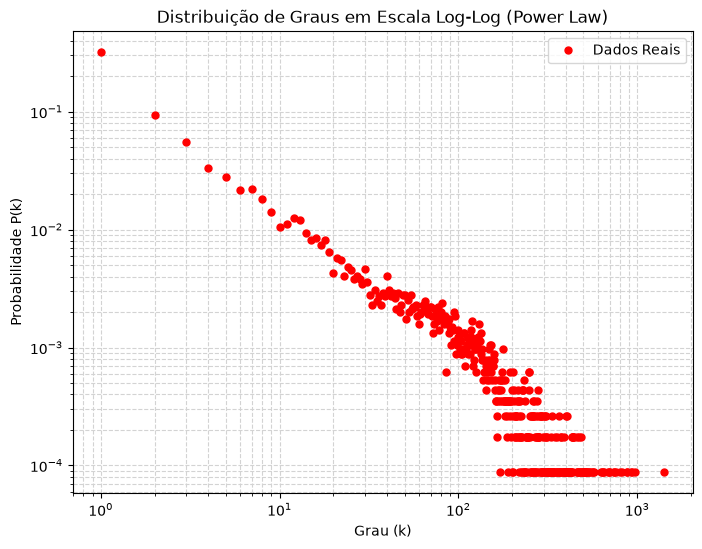

In [23]:
# Contagem para o gráfico Log-Log
contador_graus = collections.Counter(graus)
graus_unicos = sorted(contador_graus.keys())
P_k = [contador_graus[k] / num_vertices for k in graus_unicos]

plt.figure(figsize=(8, 6))
plt.loglog(graus_unicos, P_k, 'ro', markersize=5, label='Dados Reais')
plt.title('Distribuição de Graus em Escala Log-Log (Power Law)')
plt.xlabel('Grau (k)')
plt.ylabel('Probabilidade P(k)')
plt.grid(True, which="both", ls="--", color='lightgray')
plt.legend()
plt.show()

Gerando visualização da versão reduzida do grafo para o relatório...


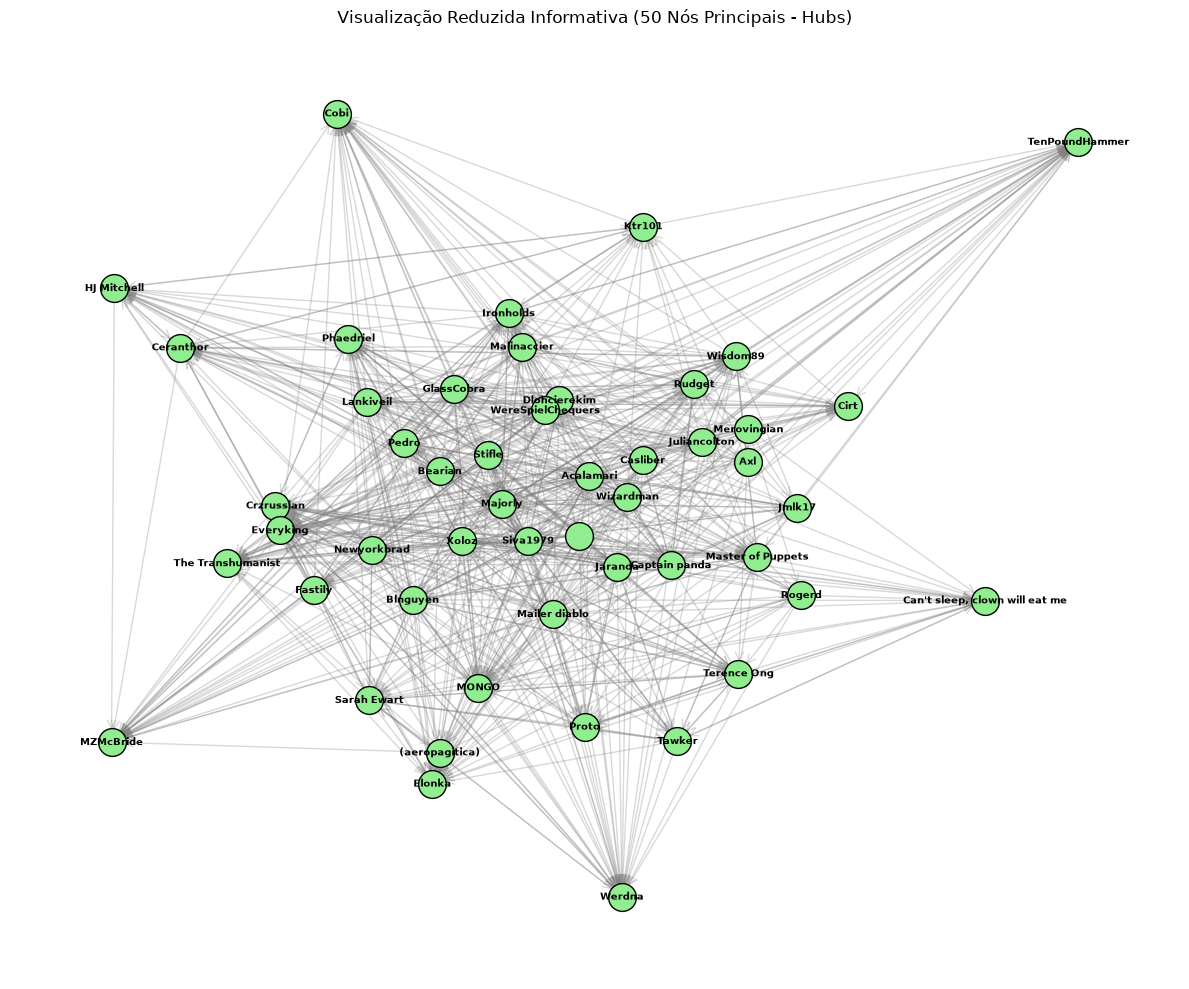

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

print("Gerando visualização da versão reduzida do grafo")
plt.figure(figsize=(12, 10))

# Extrai os 50 nós mais centrais/conectados do grafo completo (G_maior)
nos_explicativos = sorted(G_maior.nodes(), key=lambda n: G_maior.degree(n), reverse=True)[:50]
subgrafo_visualizacao = G.subgraph(nos_explicativos)

pos = nx.spring_layout(subgrafo_visualizacao, k=0.85, seed=42)

# Desenha vértices, arestas e rótulos
nx.draw_networkx_nodes(subgrafo_visualizacao, pos, node_size=400, node_color='lightgreen', edgecolors='black')
nx.draw_networkx_edges(subgrafo_visualizacao, pos, alpha=0.3, edge_color='gray', arrowstyle='->', arrowsize=15)
nx.draw_networkx_labels(subgrafo_visualizacao, pos, font_size=7, font_family='sans-serif', font_weight='bold')

plt.title("Visualização Reduzida Informativa (50 Nós Principais - Hubs)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def verificar_eulerianidade(G):
    # Verifica se o grafo é fortemente conexo
    if not nx.is_strongly_connected(G):
        return False, "O grafo não é fortemente conexo."
    
    # Verifica se o grau de entrada == grau de saída para todos os nós
    for node in G.nodes():
        if G.in_degree(node) != G.out_degree(node):
            return False, f"O nó {node} possui grau de entrada {G.in_degree(node)} != grau de saída {G.out_degree(node)}."
            
    return True, "O grafo é Euleriano"

is_eulerian, mensagem = verificar_eulerianidade(G)
print(f"Verificação de Eulerianidade: {mensagem}")

Verificação de Eulerianidade: O grafo não é fortemente conexo.


In [ ]:
print("--- Preparando pares válidos para testes de tempo (30 repetições) ---")
nodos_maior = list(G_maior.nodes())
pares_validos = []

# Garante que temos 30 pares com conectividade antes de iniciar o relógio
while len(pares_validos) < 30:
    s = random.choice(nodos_maior)
    t = random.choice(nodos_maior)
    if s != t and nx.has_path(G_maior, s, t):
        pares_validos.append((s, t))

def medir_tempo_algoritmo(funcao, nome):
    tempos = []
    for s, t in pares_validos:
        inicio = time.perf_counter()
        funcao(G_maior, s, t)
        fim = time.perf_counter()
        tempos.append(fim - inicio)
        
    media = statistics.mean(tempos)
    desvio = statistics.stdev(tempos)
    ic = st.norm.interval(0.95, loc=media, scale=st.sem(tempos))
    print(f"{nome:8} -> Média: {media:.6f}s | Desvio: {desvio:.6f}s | IC 95%: ({ic[0]:.6f}, {ic[1]:.6f})")

def run_bfs(G, s, t): list(nx.bfs_edges(G, source=s))
def run_dfs(G, s, t): list(nx.dfs_edges(G, source=s))
def run_dij(G, s, t): nx.single_source_dijkstra(G, source=s, target=t)

print("\nResultados de Desempenho:")
medir_tempo_algoritmo(run_bfs, "BFS")
medir_tempo_algoritmo(run_dfs, "DFS")
medir_tempo_algoritmo(run_dij, "Dijkstra")

--- Preparando pares válidos para testes de tempo (30 repetições) ---

Resultados de Desempenho:
BFS      -> Média: 0.388155s | Desvio: 1.086946s | IC 95%: (-0.000796, 0.777107)
DFS      -> Média: 0.175756s | Desvio: 0.128656s | IC 95%: (0.129718, 0.221794)
Dijkstra -> Média: 0.191537s | Desvio: 0.115648s | IC 95%: (0.150154, 0.232921)


In [27]:
tempos_tarjan, tempos_kruskal = [], []

print("Executando Tarjan (30x)...")
for _ in range(30):
    inicio = time.perf_counter()
    sccs = list(nx.strongly_connected_components(G))
    tempos_tarjan.append(time.perf_counter() - inicio)

print("Executando Kruskal (30x)...")
for _ in range(30):
    inicio = time.perf_counter()
    agm = nx.minimum_spanning_tree(G_maior_undirected, algorithm="kruskal")
    tempos_kruskal.append(time.perf_counter() - inicio)

def print_stats(tempos, nome):
    med = statistics.mean(tempos)
    desv = statistics.stdev(tempos)
    print(f"{nome}: Média={med:.4f}s | Desvio={desv:.4f}s")

print_stats(tempos_tarjan, "Tarjan")
print(f"-> Maior SCC detectada: {len(max(sccs, key=len))} nós")

print("\n")
print_stats(tempos_kruskal, "Kruskal")
print(f"-> Vértices na AGM: {agm.number_of_nodes()} | Arestas: {agm.number_of_edges()}")

Executando Tarjan (30x)...
Executando Kruskal (30x)...
Tarjan: Média=0.2765s | Desvio=0.1461s
-> Maior SCC detectada: 2449 nós


Kruskal: Média=1.3575s | Desvio=0.2909s
-> Vértices na AGM: 11381 | Arestas: 11380


--- Teste de Robustez (Remoção de 5%) ---
Total de nós: 11381 | A remover (5%): 569
Executando 30 repetições de ataques aleatórios...
Executando ataque direcionado aos Hubs...

=== RESULTADOS PARA O RELATÓRIO ===
Métrica A (S_rand - Maior Componente): Média 0.9340 | Ataque Hubs: 0.7966
Métrica B (Total Componentes): Média 182.8 | Ataque Hubs: 1744
Métrica D (Nós Isolados): Média 1.59% | Ataque Hubs: 15.29%


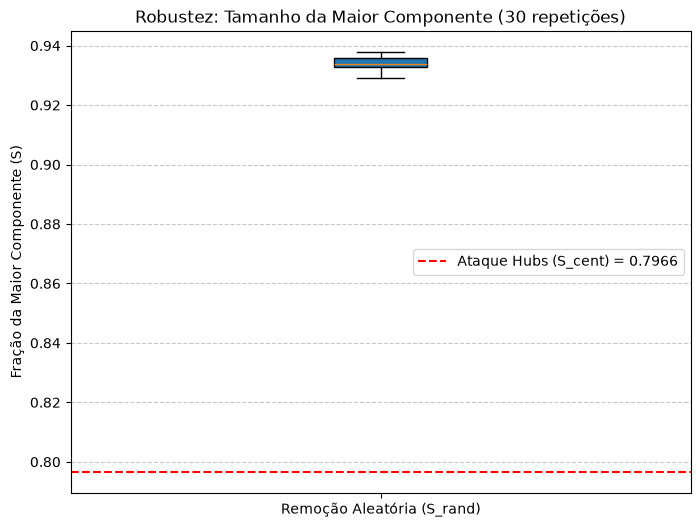

In [ ]:
import matplotlib.pyplot as plt
import random
import statistics
import networkx as nx

print("--- Teste de Robustez (Remoção de 5%) ---")
G_base = G_maior_undirected.copy()
V_total = G_base.number_of_nodes()
n_remover = int(0.05 * V_total)

print(f"Total de nós: {V_total} | A remover (5%): {n_remover}")

# CENÁRIO A: Remoção Aleatória (30 repetições)
print("Executando 30 repetições de ataques aleatórios...")
S_rand_list = []
comp_rand_list = []
isolados_rand_list = []

for _ in range(30):
    G_rand = G_base.copy()
    nos_aleatorios = random.sample(list(G_rand.nodes()), n_remover)
    G_rand.remove_nodes_from(nos_aleatorios)
    
    comp_rand = list(nx.connected_components(G_rand))
    S_rand_list.append(len(max(comp_rand, key=len)) / V_total)
    comp_rand_list.append(len(comp_rand))
    isolados_rand_list.append(nx.number_of_isolates(G_rand) / V_total)

# CENÁRIO B: Ataque a Hubs
print("Executando ataque direcionado aos Hubs...")
G_ataque = G_base.copy()
hubs_para_remover = [no for no, grau in sorted(G_ataque.degree(), key=lambda x: x[1], reverse=True)[:n_remover]]
G_ataque.remove_nodes_from(hubs_para_remover)

comp_ataque = list(nx.connected_components(G_ataque))
S_cent = len(max(comp_ataque, key=len)) / V_total
num_comp_ataque = len(comp_ataque)
isolados_ataque = nx.number_of_isolates(G_ataque) / V_total

print("\n=== RESULTADOS PARA O RELATÓRIO ===")
print(f"Métrica A (S_rand - Maior Componente): Média {statistics.mean(S_rand_list):.4f} | Ataque Hubs: {S_cent:.4f}")
print(f"Métrica B (Total Componentes): Média {statistics.mean(comp_rand_list):.1f} | Ataque Hubs: {num_comp_ataque}")
print(f"Métrica D (Nós Isolados): Média {statistics.mean(isolados_rand_list)*100:.2f}% | Ataque Hubs: {isolados_ataque*100:.2f}%")

plt.figure(figsize=(8, 6))
plt.boxplot([S_rand_list], tick_labels=['Remoção Aleatória (S_rand)'], patch_artist=True)

plt.axhline(y=S_cent, color='r', linestyle='--', label=f'Ataque Hubs (S_cent) = {S_cent:.4f}')
plt.title('Robustez: Tamanho da Maior Componente (30 repetições)')
plt.ylabel('Fração da Maior Componente (S)')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()